# Lasso Regression — An Illustrated Tour

> Where Ridge *shrinks* coefficients, **Lasso** *zeros them out* — performing automatic feature selection.

---

**What we cover:**
- The sparse signal problem — many features, few relevant
- The Lasso cost: $J(\theta) + \lambda \|\theta\|_1$
- Why L1 (not L2) creates exact zeros — the diamond geometry
- The regularisation path — features dropping out as $\lambda$ grows
- Lasso vs Ridge on a sparse problem
- Cross-validation for $\lambda$

## The picture — sparsity path, coefficients hit zero one by one

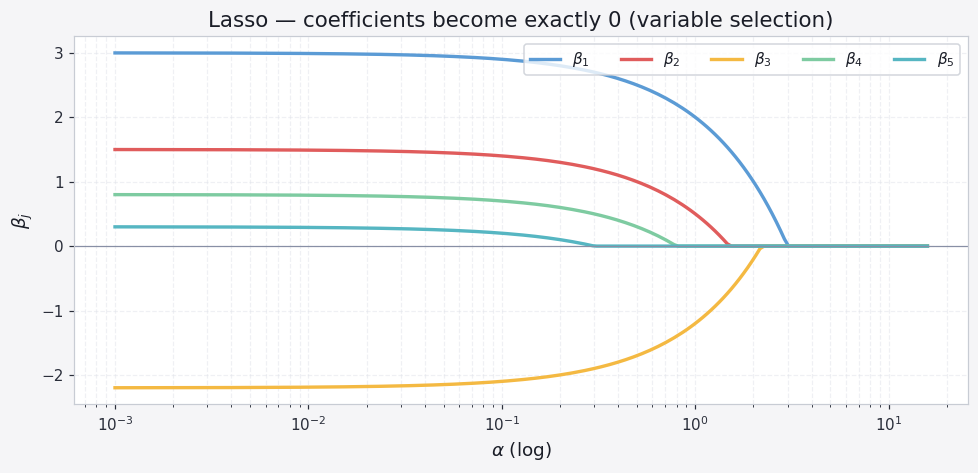

In [1]:
# (schematic — drawn from smooth curves, not measured)
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import FancyArrow, FancyBboxPatch, Ellipse, Rectangle, Circle, FancyArrowPatch
plt.rcParams.update({
    'figure.facecolor':'#f5f5f7','axes.facecolor':'#ffffff','axes.edgecolor':'#c8ccd4',
    'axes.labelcolor':'#1a1d27','axes.titlecolor':'#1a1d27','xtick.color':'#2a2e3a',
    'ytick.color':'#2a2e3a','grid.color':'#e0e3ea','grid.linestyle':'--','grid.alpha':0.5,
    'text.color':'#1a1d27','font.family':'DejaVu Sans','axes.titlesize':14,'axes.labelsize':12,
    'legend.facecolor':'#ffffff','legend.edgecolor':'#c8ccd4','figure.dpi':110,
})
P = ['#5b9bd5','#e05c5c','#f4b942','#7ecba1','#56b6c2','#c678dd','#888fa5','#d68a3c']
alphas = np.logspace(-3, 1.2, 200)
def soft(x, a): return np.sign(x)*np.maximum(0, np.abs(x)-a)
true = np.array([3.0, 1.5, -2.2, 0.8, 0.3])
coefs = np.array([soft(true, a) for a in alphas])
fig, ax = plt.subplots(figsize=(9, 4.4))
for i in range(coefs.shape[1]):
    ax.plot(alphas, coefs[:, i], color=P[i % len(P)], lw=2.2, label=rf'$\beta_{i+1}$')
ax.set_xscale('log'); ax.axhline(0, color='#888fa5', lw=0.8)
ax.set_xlabel(r'$\alpha$ (log)'); ax.set_ylabel(r'$\beta_j$')
ax.set_title('Lasso — coefficients become exactly 0 (variable selection)')
ax.legend(ncol=5); ax.grid(True, which='both'); plt.tight_layout(); plt.show()


In [2]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec
from matplotlib.patches import FancyArrowPatch
from sklearn.linear_model import Lasso, Ridge, LinearRegression, LassoCV
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import cross_val_score, KFold
from sklearn.metrics import mean_squared_error

# ── Presentation style ─────────────────────────────────────────────────────
PLT_STYLE = {
    'figure.facecolor':'#f5f5f7', 'axes.facecolor':'#ffffff',
    'axes.edgecolor':'#c8ccd4',   'axes.labelcolor':'#1a1d27',
    'axes.titlecolor':'#1a1d27',  'xtick.color':'#2a2e3a',
    'ytick.color':'#2a2e3a',      'grid.color':'#e0e3ea',
    'grid.linestyle': '--',        'grid.alpha': 0.5,
    'text.color':'#1a1d27',       'font.family': 'DejaVu Sans',
    'axes.titlesize': 17,          'axes.labelsize': 13,
    'xtick.labelsize': 11,         'ytick.labelsize': 11,
    'legend.fontsize': 11,         'legend.facecolor':'#ffffff',
    'legend.edgecolor':'#c8ccd4', 'figure.dpi': 120,
}
plt.rcParams.update(PLT_STYLE)

C_DATA  = '#5b9bd5'   # data
C_LASSO = '#f4b942'   # Lasso
C_RIDGE = '#56b6c2'   # Ridge
C_ZERO  = '#e05c5c'   # zeroed-out coefficient
C_TRUE  = '#7ecba1'   # true / relevant feature
C_HL    = '#c678dd'   # highlight

# ── Sparse dataset ─────────────────────────────────────────────────────────
np.random.seed(42)
n_samples,  n_features  = 60, 20
n_relevant               = 5   # only these matter

X_raw = np.random.randn(n_samples, n_features)
theta_true = np.zeros(n_features)
theta_true[:n_relevant] = np.array([3.0, -2.5, 1.8, -1.2, 2.2])
np.random.shuffle(theta_true)            # shuffle so relevant not always first
y_raw = X_raw @ theta_true + np.random.randn(n_samples) * 0.5

scaler = StandardScaler()
X_sc   = scaler.fit_transform(X_raw)

print(f'Dataset: {n_samples} samples  |  {n_features} features  |  {n_relevant} truly relevant')
print(f'True non-zero indices: {np.where(theta_true != 0)[0].tolist()}')

Dataset: 60 samples  |  20 features  |  5 truly relevant
True non-zero indices: [0, 1, 4, 6, 12]


---
## The Sparse Signal Problem

We have **20 features** but only **5 are truly relevant** — the rest are pure noise.
OLS uses all 20 and picks up noise. We want a method that **automatically discards** the irrelevant ones.

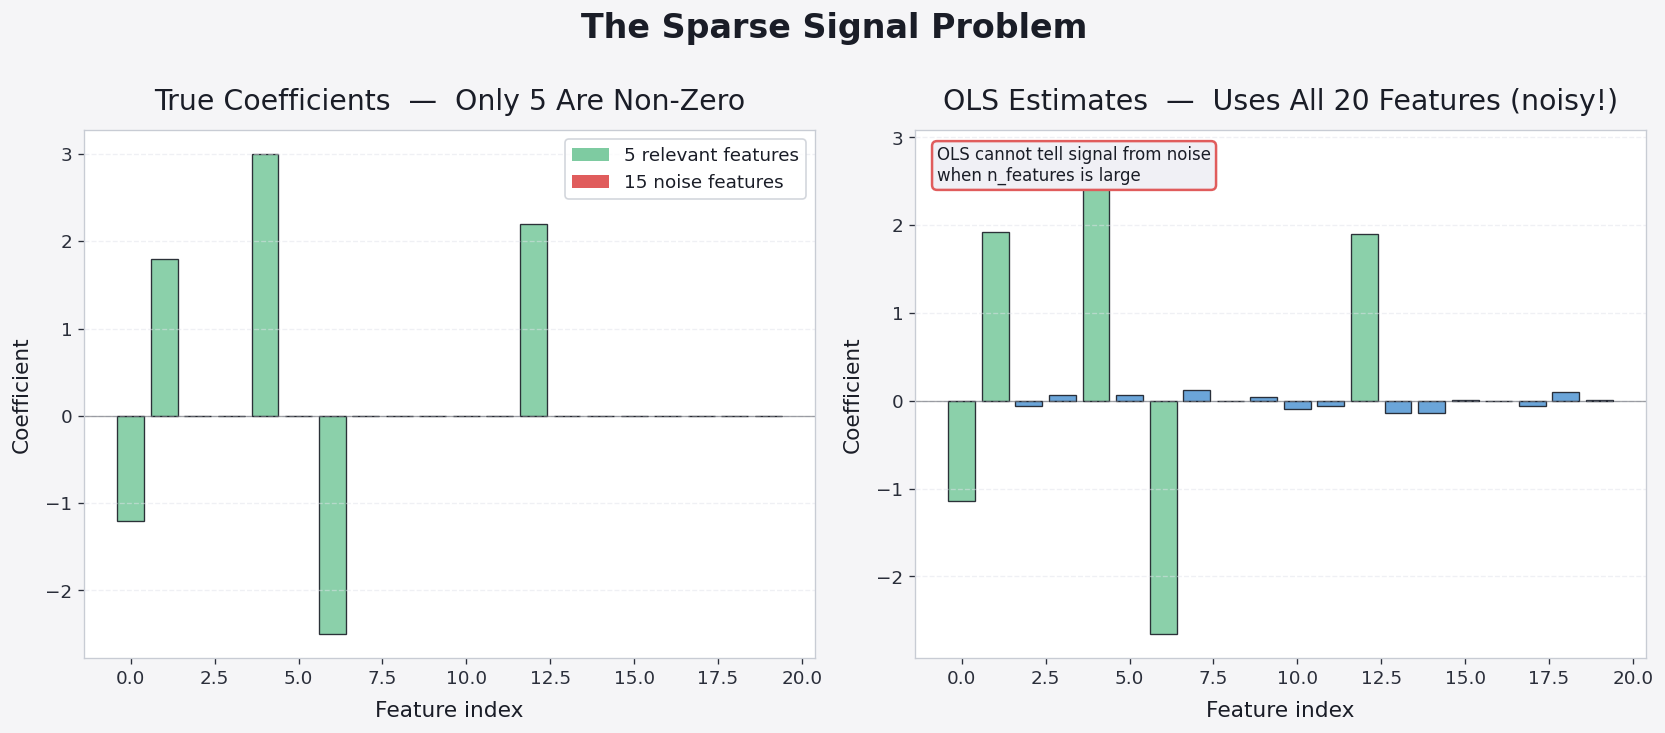

In [3]:
ols = LinearRegression().fit(X_sc, y_raw)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

feature_idx = np.arange(n_features)
relevant    = np.where(theta_true != 0)[0]
irrelevant  = np.where(theta_true == 0)[0]

# Left: true coefficients
ax = axes[0]
ax.bar(feature_idx, theta_true,
       color=[C_TRUE if i in relevant else C_ZERO for i in range(n_features)],
       edgecolor='#1a1d27', linewidth=0.8, alpha=0.9)
ax.axhline(0, color='#1a1d27', lw=0.8, alpha=0.4)
ax.set_xlabel('Feature index', labelpad=8); ax.set_ylabel('Coefficient', labelpad=8)
ax.set_title('True Coefficients  —  Only 5 Are Non-Zero', pad=12)
ax.grid(True, axis='y')
from matplotlib.patches import Patch
ax.legend(handles=[
    Patch(facecolor=C_TRUE,  label=f'{n_relevant} relevant features'),
    Patch(facecolor=C_ZERO,  label=f'{n_features-n_relevant} noise features'),
], loc='upper right')

# Right: OLS estimates
ax = axes[1]
ax.bar(feature_idx, ols.coef_,
       color=[C_TRUE if i in relevant else C_DATA for i in range(n_features)],
       edgecolor='#1a1d27', linewidth=0.8, alpha=0.9)
ax.axhline(0, color='#1a1d27', lw=0.8, alpha=0.4)
ax.set_xlabel('Feature index', labelpad=8); ax.set_ylabel('Coefficient', labelpad=8)
ax.set_title('OLS Estimates  —  Uses All 20 Features (noisy!)', pad=12)
ax.grid(True, axis='y')
ax.text(0.03, 0.97, 'OLS cannot tell signal from noise\nwhen n_features is large',
        transform=ax.transAxes, fontsize=10, va='top',
        bbox=dict(boxstyle='round', fc='#f0f0f5', ec=C_ZERO, lw=1.5))

fig.suptitle('The Sparse Signal Problem', fontsize=20, fontweight='bold', y=1.01)
plt.tight_layout(); plt.show()

---
## The Lasso Cost — Annotated

Lasso adds an **L1 penalty** to the OLS cost — the *sum of absolute values* of the coefficients.
The single change from Ridge ($\|\theta\|_2^2$ → $\|\theta\|_1$) is what creates exact zeros.


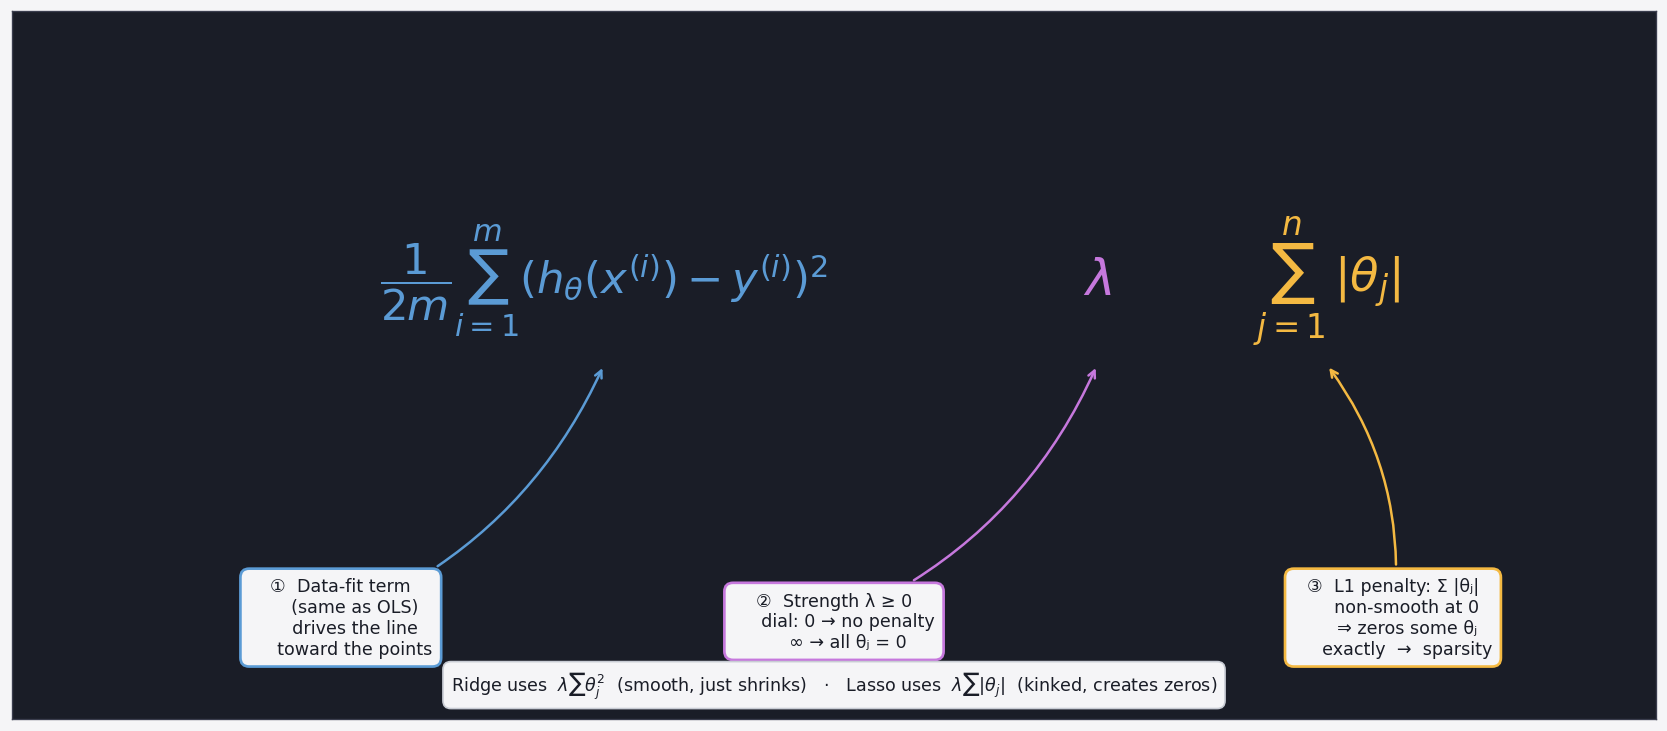

In [4]:
fig, ax = plt.subplots(figsize=(14, 6.2), facecolor='#f5f5f7')
ax.set_facecolor('#1a1d27')
ax.set_xlim(0, 1); ax.set_ylim(0, 1)
ax.set_xticks([]); ax.set_yticks([])
for s in ax.spines.values(): s.set_color('#3a3d4d')

# ── The equation, big and centred ────────────────────────────────────────
# Render in two coloured halves so each side is easy to point at.
ax.text(0.36, 0.62,
        r'$\dfrac{1}{2m}\sum_{i=1}^{m}(h_\theta(x^{(i)})-y^{(i)})^{2}$',
        fontsize=26, color=C_DATA, ha='center', va='center')
ax.text(0.58, 0.62, r'$+$', fontsize=28, color='#1a1d27', ha='center', va='center')
ax.text(0.66, 0.62, r'$\lambda$', fontsize=30, color=C_HL, ha='center', va='center')
ax.text(0.80, 0.62, r'$\sum_{j=1}^{n}\,|\theta_j|$',
        fontsize=28, color=C_LASSO, ha='center', va='center')

ax.text(0.50, 0.92, 'The Lasso Cost  $J_{\\mathrm{Lasso}}(\\theta)$',
        ha='center', fontsize=18, color='#1a1d27', fontweight='bold')
ax.text(0.07, 0.62, r'$=$', fontsize=28, color='#1a1d27', ha='center', va='center')
ax.text(0.03, 0.62, r'$J_{\mathrm{L}}$', fontsize=22, color='#1a1d27', ha='center', va='center')

# ── Callouts: anchor → box (with leader arrows) ──────────────────────────
callouts = [
    # (anchor_x, anchor_y, box_x, box_y, text, colour)
    (0.36, 0.50, 0.20, 0.20,
     '①  Data-fit term\n     (same as OLS)\n     drives the line\n     toward the points',
     C_DATA),
    (0.66, 0.50, 0.50, 0.18,
     '②  Strength λ ≥ 0\n     dial: 0 → no penalty\n     ∞ → all θⱼ = 0',
     C_HL),
    (0.80, 0.50, 0.84, 0.20,
     '③  L1 penalty: Σ |θⱼ|\n     non-smooth at 0\n     ⇒ zeros some θⱼ\n     exactly  →  sparsity',
     C_LASSO),
]
for ax_x, ax_y, bx, by, txt, col in callouts:
    ax.annotate(txt,
                xy=(ax_x, ax_y), xytext=(bx, by),
                fontsize=10.5, color='#1a1d27', ha='center', va='top',
                bbox=dict(boxstyle='round,pad=0.5', fc='#f5f5f7', ec=col, lw=1.6),
                arrowprops=dict(arrowstyle='->', color=col, lw=1.5,
                                connectionstyle='arc3,rad=0.20'))

# Contrast badge
ax.text(0.50, 0.04,
        'Ridge uses  $\\lambda\\sum\\theta_j^{2}$  (smooth, just shrinks)   '
        '·   Lasso uses  $\\lambda\\sum|\\theta_j|$  (kinked, creates zeros)',
        ha='center', fontsize=10.5, color='#1a1d27',
        bbox=dict(boxstyle='round,pad=0.45', fc='#f5f5f7', ec='#c8ccd4', lw=1))

plt.tight_layout()
plt.show()


---
## Why L1 Creates Exact Zeros — the Geometry

Both Lasso and Ridge can be viewed as **constrained optimisation**:

| Method | Constraint | Shape |
|---|---|---|
| Ridge | $\|\theta\|_2^2 \leq t$ | **Sphere** — smooth, no corners |
| Lasso | $\|\theta\|_1 \leq t$ | **Diamond** — sharp corners on the axes |

The OLS cost function (elliptical contours) almost always touches the **diamond's corner** first,
where one or more $\theta_j = 0$ exactly.

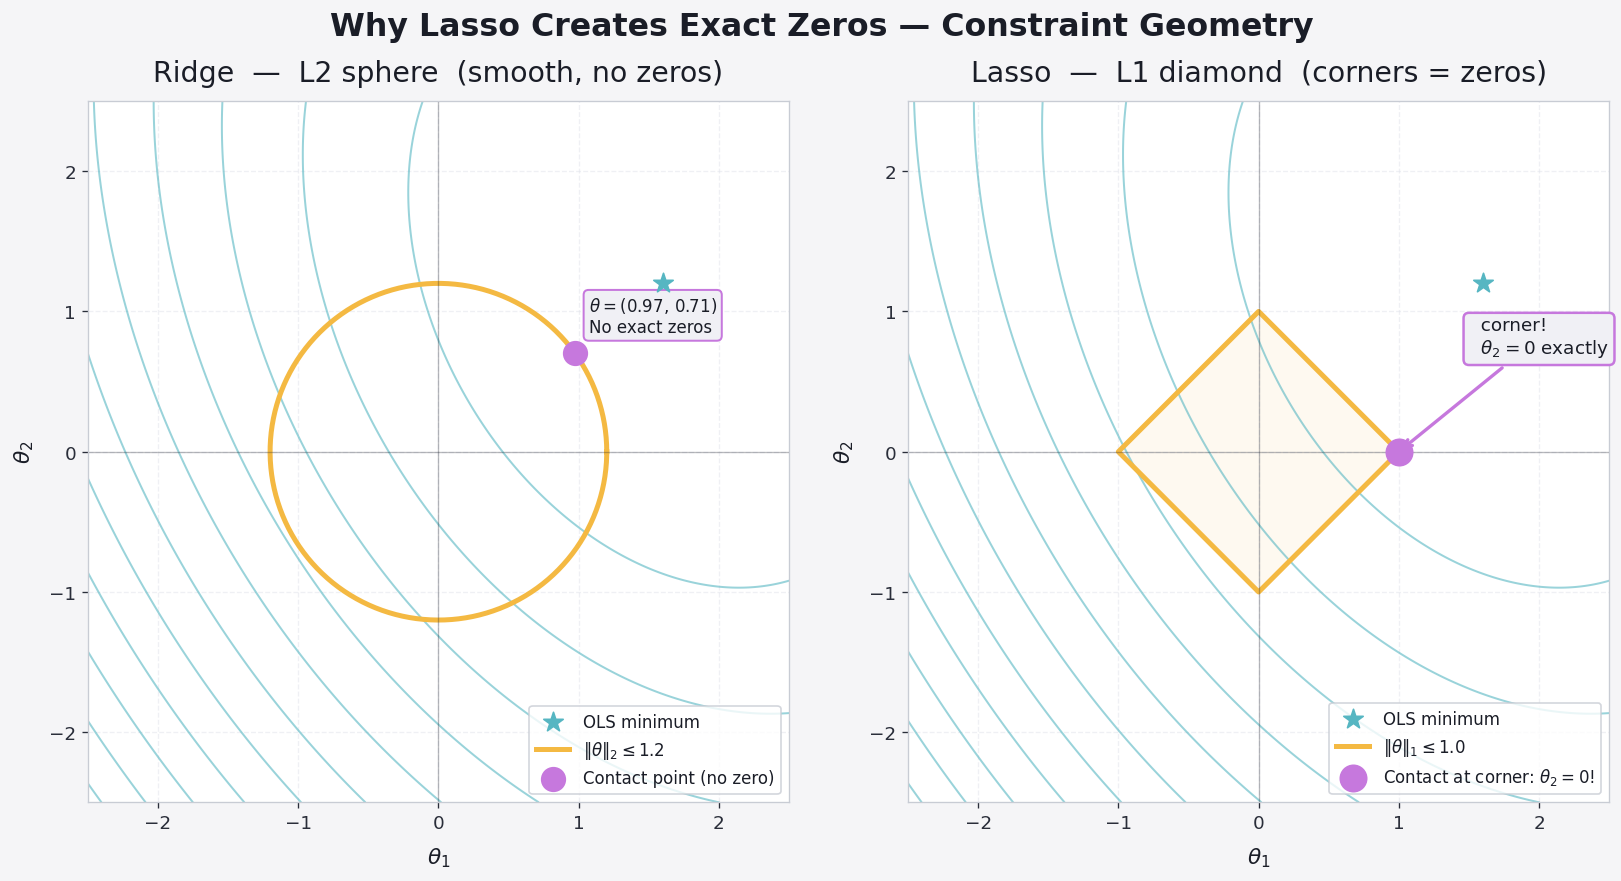

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(14, 7))

theta1 = np.linspace(-2.5, 2.5, 400)
theta2 = np.linspace(-2.5, 2.5, 400)
T1, T2 = np.meshgrid(theta1, theta2)

# OLS cost centred away from origin
T1_ols, T2_ols = 1.6, 1.2   # OLS minimum
J_ols = (T1 - T1_ols)**2 + 0.7*(T2 - T2_ols)**2 + 0.5*(T1-T1_ols)*(T2-T2_ols)

for ax, title, constraint_r, label in zip(
    axes,
    ['Ridge  —  L2 sphere  (smooth, no zeros)', 'Lasso  —  L1 diamond  (corners = zeros)'],
    [1.2, 1.0],
    ['Ridge', 'Lasso']
):
    # OLS cost contours
    ax.contour(T1, T2, J_ols, levels=12, colors='#56b6c2', linewidths=1.2, alpha=0.6)
    ax.scatter([T1_ols], [T2_ols], s=150, c=C_RIDGE, marker='*', zorder=7,
               label='OLS minimum')

    if label == 'Ridge':
        # L2 ball (circle)
        theta_ang = np.linspace(0, 2*np.pi, 300)
        ax.plot(constraint_r * np.cos(theta_ang), constraint_r * np.sin(theta_ang),
                color=C_LASSO, lw=3, label=f'$\\|\\theta\\|_2 \\leq {constraint_r}$')
        # Contact point (not on axis → no zeros)
        contact_t1 =  constraint_r * np.cos(np.pi/5)
        contact_t2 =  constraint_r * np.sin(np.pi/5)
        ax.scatter([contact_t1], [contact_t2], s=200, c=C_HL, zorder=8,
                   label='Contact point (no zero)')
        ax.text(contact_t1+0.1, contact_t2+0.15,
                f'$\\theta = ({contact_t1:.2f},\\, {contact_t2:.2f})$\nNo exact zeros',
                fontsize=10, color='#1a1d27',
                bbox=dict(boxstyle='round', fc='#f0f0f5', ec=C_HL, lw=1.2))
    else:
        # L1 ball (diamond)
        diamond_x = np.array([constraint_r, 0, -constraint_r, 0, constraint_r])
        diamond_y = np.array([0, constraint_r, 0, -constraint_r, 0])
        ax.plot(diamond_x, diamond_y, color=C_LASSO, lw=3,
                label=f'$\\|\\theta\\|_1 \\leq {constraint_r}$')
        ax.fill(diamond_x, diamond_y, color=C_LASSO, alpha=0.08)
        # Contact point at a corner (one zero)
        ax.scatter([constraint_r], [0], s=250, c=C_HL, zorder=8,
                   label='Contact at corner: $\\theta_2=0$!')
        ax.annotate('  corner!\n  $\\theta_2 = 0$ exactly',
                    xy=(constraint_r, 0), xytext=(1.5, 0.7),
                    fontsize=11, color='#1a1d27',
                    bbox=dict(boxstyle='round', fc='#f0f0f5', ec=C_HL, lw=1.5),
                    arrowprops=dict(arrowstyle='->', color=C_HL, lw=2))

    ax.axhline(0, color='#1a1d27', lw=0.8, alpha=0.3)
    ax.axvline(0, color='#1a1d27', lw=0.8, alpha=0.3)
    ax.set_xlabel('$\\theta_1$', labelpad=8); ax.set_ylabel('$\\theta_2$', labelpad=8)
    ax.set_title(title, pad=12)
    ax.set_xlim(-2.5, 2.5); ax.set_ylim(-2.5, 2.5)
    ax.set_aspect('equal')
    ax.legend(loc='lower right', fontsize=10)
    ax.grid(True)

fig.suptitle('Why Lasso Creates Exact Zeros — Constraint Geometry',
             fontsize=19, fontweight='bold', y=1.01)
plt.tight_layout(); plt.show()

---
## Visual Sweep — Watch Features Drop Out

The grid below shows six fixed values of $\lambda$ from weak (Lasso ≈ OLS, all 20 features alive) to strong (everything zeroed). In each bar chart, **green bars** are true-signal features the model kept, **coral bars** are noise features the model wrongly kept, and **grey bars** are features the model dropped.

The follow-up shows the **regularisation path** — number of non-zero coefficients as $\lambda$ grows — with the six sweep values marked.


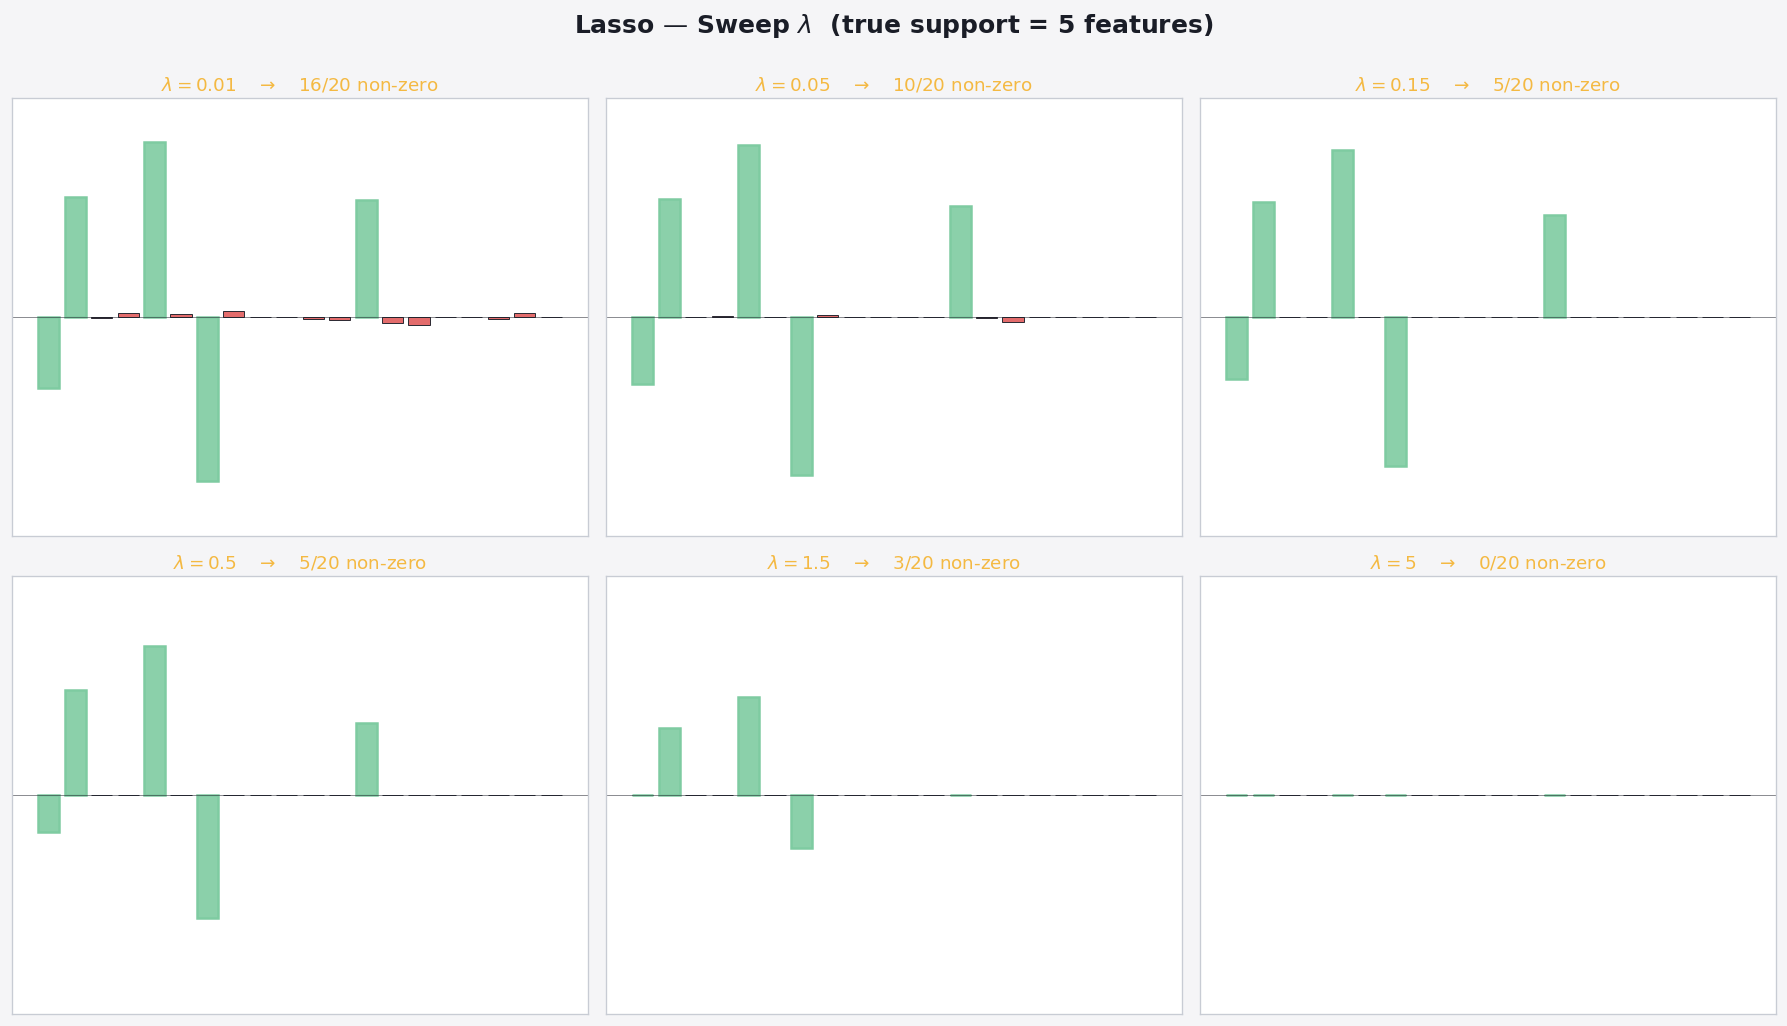

In [6]:
# Local α grid + path for the sweep curve
_alphas_local = np.logspace(-2, 1, 120)
_path_local   = np.array([
    Lasso(alpha=a, max_iter=5000).fit(X_sc, y_raw).coef_
    for a in _alphas_local
])
_nz_local = np.sum(np.abs(_path_local) > 1e-4, axis=1)

# Six representative λ values: weak → strong
_lam_panel = [0.01, 0.05, 0.15, 0.5, 1.5, 5.0]

fig, axes = plt.subplots(2, 3, figsize=(15, 8.5))
for ax, lam in zip(axes.ravel(), _lam_panel):
    coef = Lasso(alpha=lam, max_iter=10000).fit(X_sc, y_raw).coef_
    n_nz = int(np.sum(np.abs(coef) > 1e-4))

    bar_colors = [
        C_TRUE  if (theta_true[i] != 0) and (abs(coef[i]) > 1e-4) else
        C_ZERO  if (theta_true[i] == 0) and (abs(coef[i]) > 1e-4) else
        '#3a3d60'
        for i in range(n_features)
    ]
    ax.bar(feature_idx, coef, color=bar_colors,
           edgecolor='#1a1d27', lw=0.6, alpha=0.9)
    for i in relevant:
        ax.bar([i], [coef[i]], facecolor='none', edgecolor=C_TRUE, lw=1.5)
    ax.axhline(0, color='#1a1d27', lw=0.6, alpha=0.5)
    ax.set_ylim(-3.5, 3.5)
    ax.set_title(f'$\\lambda = {lam:g}$    →    {n_nz}/{n_features} non-zero',
                 color=C_LASSO, fontsize=11, pad=4)
    ax.set_xticks([]); ax.set_yticks([])
    ax.grid(True, axis='y', alpha=0.3)

fig.suptitle(f'Lasso — Sweep $\\lambda$  (true support = {n_relevant} features)',
             fontsize=15, fontweight='bold', y=1.00)
plt.tight_layout(); plt.show()


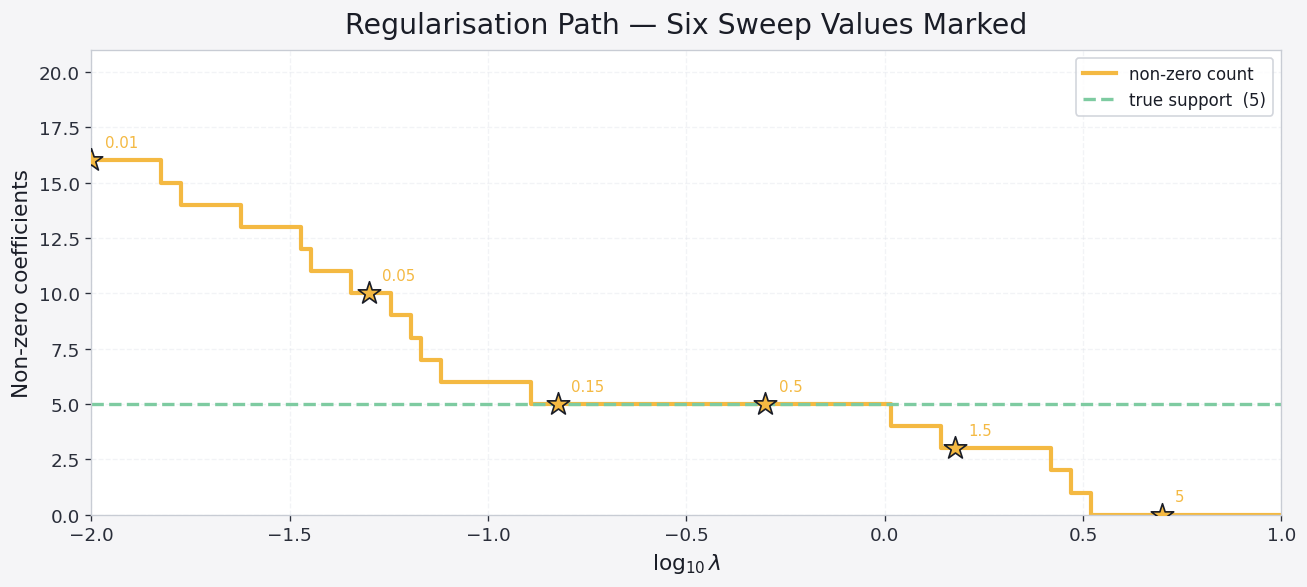

In [7]:
# Regularisation path: # of non-zero coefficients vs λ, with the six sweep values marked
fig, ax = plt.subplots(figsize=(11, 5))
ax.step(np.log10(_alphas_local), _nz_local, color=C_LASSO, lw=2.5, where='post',
        label='non-zero count')
ax.axhline(n_relevant, color=C_TRUE, ls='--', lw=2,
           label=f'true support  ({n_relevant})')

for lam in _lam_panel:
    coef = Lasso(alpha=lam, max_iter=10000).fit(X_sc, y_raw).coef_
    n_nz = int(np.sum(np.abs(coef) > 1e-4))
    ax.scatter([np.log10(lam)], [n_nz], s=200, c=C_LASSO, marker='*',
               edgecolors='#1a1d27', lw=1, zorder=8)
    ax.annotate(f'{lam:g}', (np.log10(lam), n_nz),
                textcoords='offset points', xytext=(8, 8),
                fontsize=9, color=C_LASSO)

ax.set_xlabel('$\\log_{10}\\lambda$')
ax.set_ylabel('Non-zero coefficients')
ax.set_title('Regularisation Path — Six Sweep Values Marked', pad=10)
ax.set_ylim(0, n_features + 1)
ax.set_xlim(np.log10(_alphas_local.min()), np.log10(_alphas_local.max()))
ax.grid(True, alpha=0.4)
ax.legend(loc='upper right', fontsize=10)
plt.tight_layout(); plt.show()


---
## The Regularisation Path

As $\lambda$ increases, Lasso progressively **zeroes out** coefficients one by one.
This reveals which features the model considers most important — the last to survive are the strongest signals.

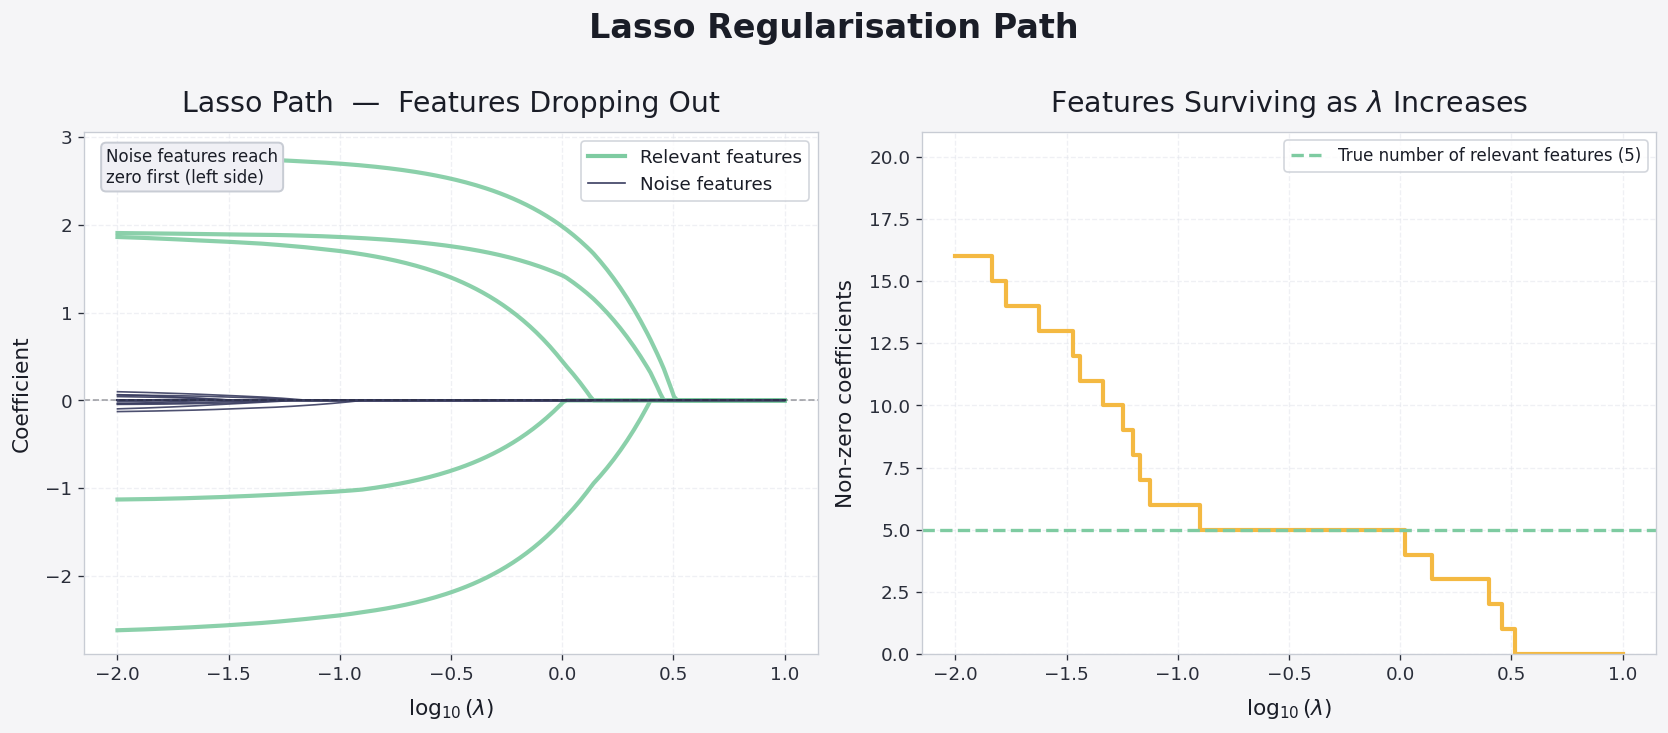

In [8]:
alphas_path = np.logspace(-2, 1, 200)
coef_path   = np.array([
    Lasso(alpha=a, max_iter=5000).fit(X_sc, y_raw).coef_
    for a in alphas_path
])

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Left: regularisation path
ax = axes[0]
cmap_r = plt.cm.plasma
for j in range(n_features):
    col = C_TRUE if j in relevant else '#3a3d60'
    lw  = 2.5 if j in relevant else 1.0
    ax.plot(np.log10(alphas_path), coef_path[:, j], color=col, lw=lw, alpha=0.9)

ax.axhline(0, color='#1a1d27', ls='--', lw=1, alpha=0.4)
ax.set_xlabel('$\\log_{10}(\\lambda)$', labelpad=8)
ax.set_ylabel('Coefficient', labelpad=8)
ax.set_title('Lasso Path  —  Features Dropping Out', pad=12)
ax.grid(True)
from matplotlib.lines import Line2D
ax.legend(handles=[
    Line2D([0],[0], color=C_TRUE, lw=2.5, label='Relevant features'),
    Line2D([0],[0], color='#3a3d60', lw=1.0, label='Noise features'),
], loc='upper right')
ax.text(0.03, 0.97, 'Noise features reach\nzero first (left side)',
        transform=ax.transAxes, fontsize=10, va='top',
        bbox=dict(boxstyle='round', fc='#f0f0f5', ec='#c8ccd4', lw=1.2))

# Right: number of non-zero coefficients vs lambda
ax = axes[1]
n_nonzero = np.sum(np.abs(coef_path) > 1e-4, axis=1)
ax.step(np.log10(alphas_path), n_nonzero, color=C_LASSO, lw=2.5, where='post')
ax.axhline(n_relevant, color=C_TRUE, ls='--', lw=2,
           label=f'True number of relevant features ({n_relevant})')
ax.set_xlabel('$\\log_{10}(\\lambda)$', labelpad=8)
ax.set_ylabel('Non-zero coefficients', labelpad=8)
ax.set_title('Features Surviving as $\\lambda$ Increases', pad=12)
ax.grid(True); ax.legend(loc='upper right', fontsize=10)
ax.set_ylim(0, n_features + 1)

fig.suptitle('Lasso Regularisation Path', fontsize=20, fontweight='bold', y=1.01)
plt.tight_layout(); plt.show()

---
## Feature Recovery

With the right $\lambda$, Lasso zeroes out all noise features and correctly identifies the 5 relevant ones.
Ridge, by contrast, keeps all 20 features small but non-zero.

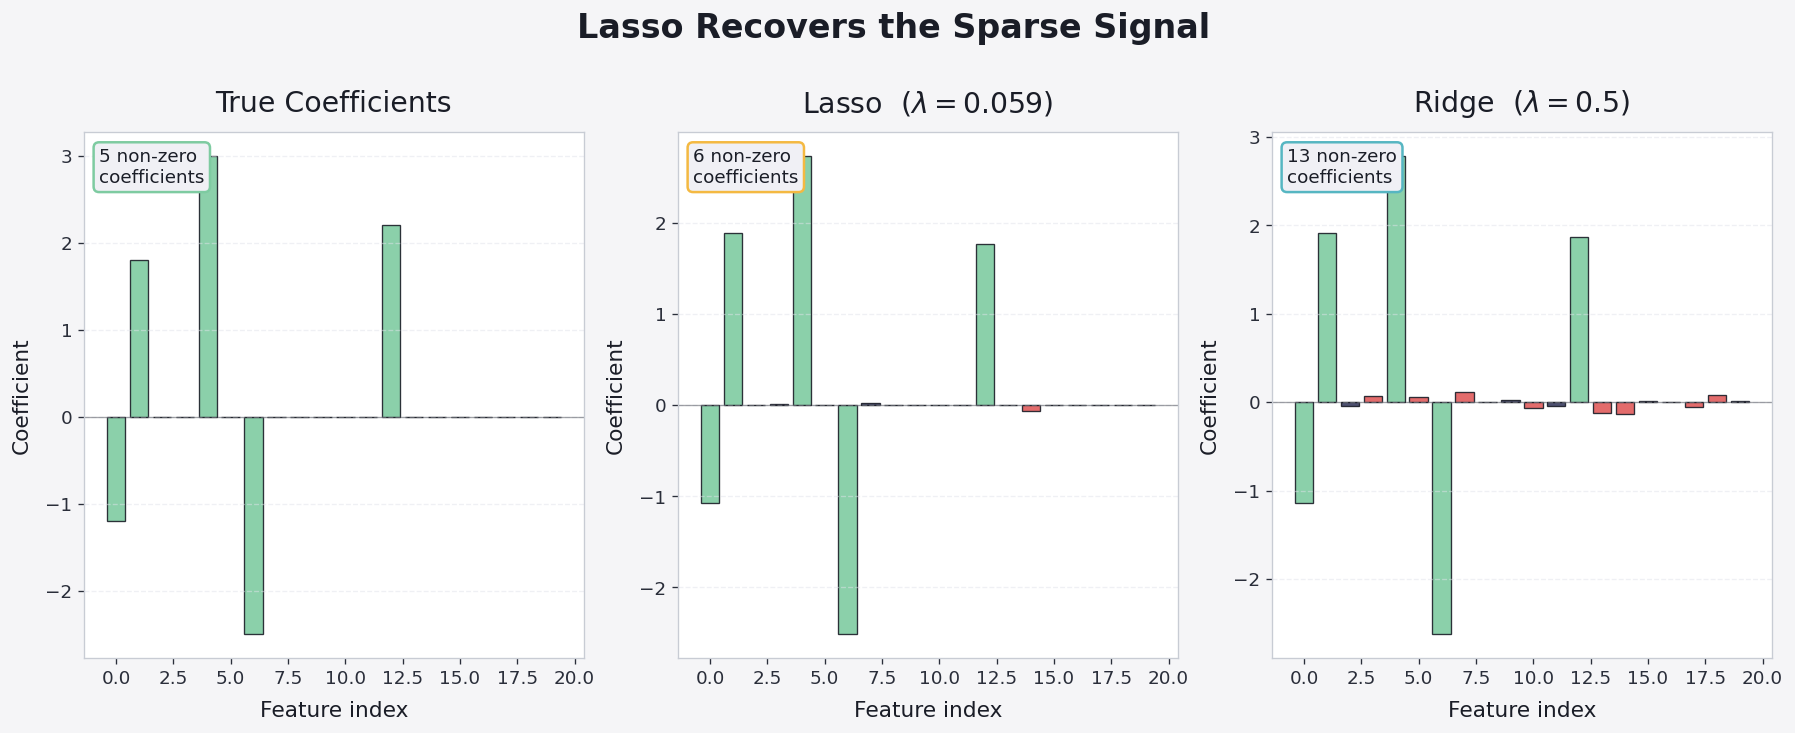

In [9]:
kf = KFold(n_splits=5, shuffle=True, random_state=1)
cv_errs = np.array([
    -cross_val_score(Lasso(alpha=a, max_iter=5000), X_sc, y_raw,
                     cv=kf, scoring='neg_mean_squared_error').mean()
    for a in alphas_path
])
best_alpha = alphas_path[np.argmin(cv_errs)]

lasso_best = Lasso(alpha=best_alpha, max_iter=5000).fit(X_sc, y_raw)
ridge_best = Ridge(alpha=0.5).fit(X_sc, y_raw)

fig, axes = plt.subplots(1, 3, figsize=(15, 6))

for ax, coef, title, col in [
    (axes[0], theta_true,        'True Coefficients',      C_TRUE),
    (axes[1], lasso_best.coef_,  f'Lasso  ($\\lambda={best_alpha:.3f}$)', C_LASSO),
    (axes[2], ridge_best.coef_,  'Ridge  ($\\lambda=0.5$)', C_RIDGE),
]:
    bar_colors = [
        C_TRUE  if (theta_true[i] != 0) else
        C_ZERO  if (abs(coef[i]) > 0.05) else '#3a3d60'
        for i in range(n_features)
    ]
    ax.bar(feature_idx, coef, color=bar_colors, edgecolor='#1a1d27', lw=0.8, alpha=0.9)
    ax.axhline(0, color='#1a1d27', lw=0.8, alpha=0.4)
    ax.set_xlabel('Feature index', labelpad=8)
    ax.set_ylabel('Coefficient', labelpad=8)
    ax.set_title(title, pad=12)
    ax.grid(True, axis='y')
    n_nonzero_here = np.sum(np.abs(coef) > 0.05)
    ax.text(0.03, 0.97, f'{n_nonzero_here} non-zero\ncoefficients',
            transform=ax.transAxes, fontsize=11, va='top',
            bbox=dict(boxstyle='round', fc='#f0f0f5', ec=col, lw=1.5))

fig.suptitle('Lasso Recovers the Sparse Signal', fontsize=20, fontweight='bold', y=1.01)
plt.tight_layout(); plt.show()

---
## Cross-Validation for $\lambda$

We use 5-fold cross-validation to find the $\lambda$ that gives the best held-out error.
Too small → uses noise features, overfits. Too large → throws away signal, underfits.

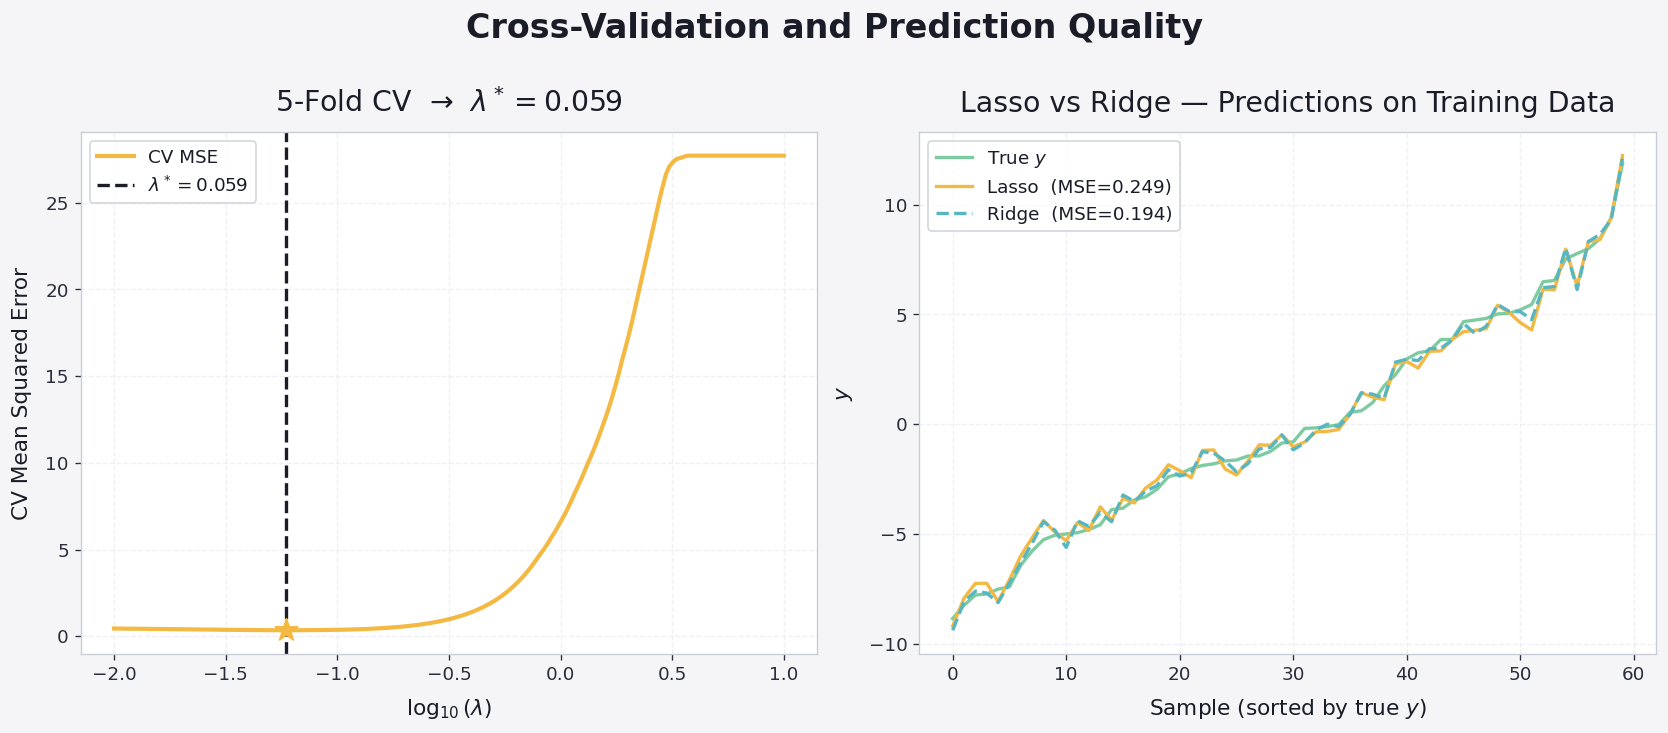

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Left: CV error vs lambda
ax = axes[0]
ax.plot(np.log10(alphas_path), cv_errs, color=C_LASSO, lw=2.5, label='CV MSE')
ax.axvline(np.log10(best_alpha), color='#1a1d27', ls='--', lw=2,
           label=f'$\\lambda^* = {best_alpha:.3f}$')
ax.scatter([np.log10(best_alpha)], [cv_errs.min()],
           s=200, c=C_LASSO, marker='*', zorder=7)
ax.set_xlabel('$\\log_{10}(\\lambda)$', labelpad=8)
ax.set_ylabel('CV Mean Squared Error', labelpad=8)
ax.set_title(f'5-Fold CV  →  $\\lambda^* = {best_alpha:.3f}$', pad=12)
ax.grid(True); ax.legend(loc='upper left')

# Right: Lasso vs Ridge prediction on train
ax = axes[1]
y_pred_lasso = lasso_best.predict(X_sc)
y_pred_ridge = ridge_best.predict(X_sc)

sort_idx = np.argsort(y_raw)
ax.plot(y_raw[sort_idx], color=C_TRUE, lw=2, label='True $y$')
ax.plot(y_pred_lasso[sort_idx], color=C_LASSO, lw=2, ls='-',
        label=f'Lasso  (MSE={mean_squared_error(y_raw, y_pred_lasso):.3f})')
ax.plot(y_pred_ridge[sort_idx], color=C_RIDGE, lw=2, ls='--',
        label=f'Ridge  (MSE={mean_squared_error(y_raw, y_pred_ridge):.3f})')
ax.set_xlabel('Sample (sorted by true $y$)', labelpad=8)
ax.set_ylabel('$y$', labelpad=8)
ax.set_title('Lasso vs Ridge — Predictions on Training Data', pad=12)
ax.grid(True); ax.legend(loc='upper left')

fig.suptitle('Cross-Validation and Prediction Quality', fontsize=20, fontweight='bold', y=1.01)
plt.tight_layout(); plt.show()

---
## Everything on One Canvas

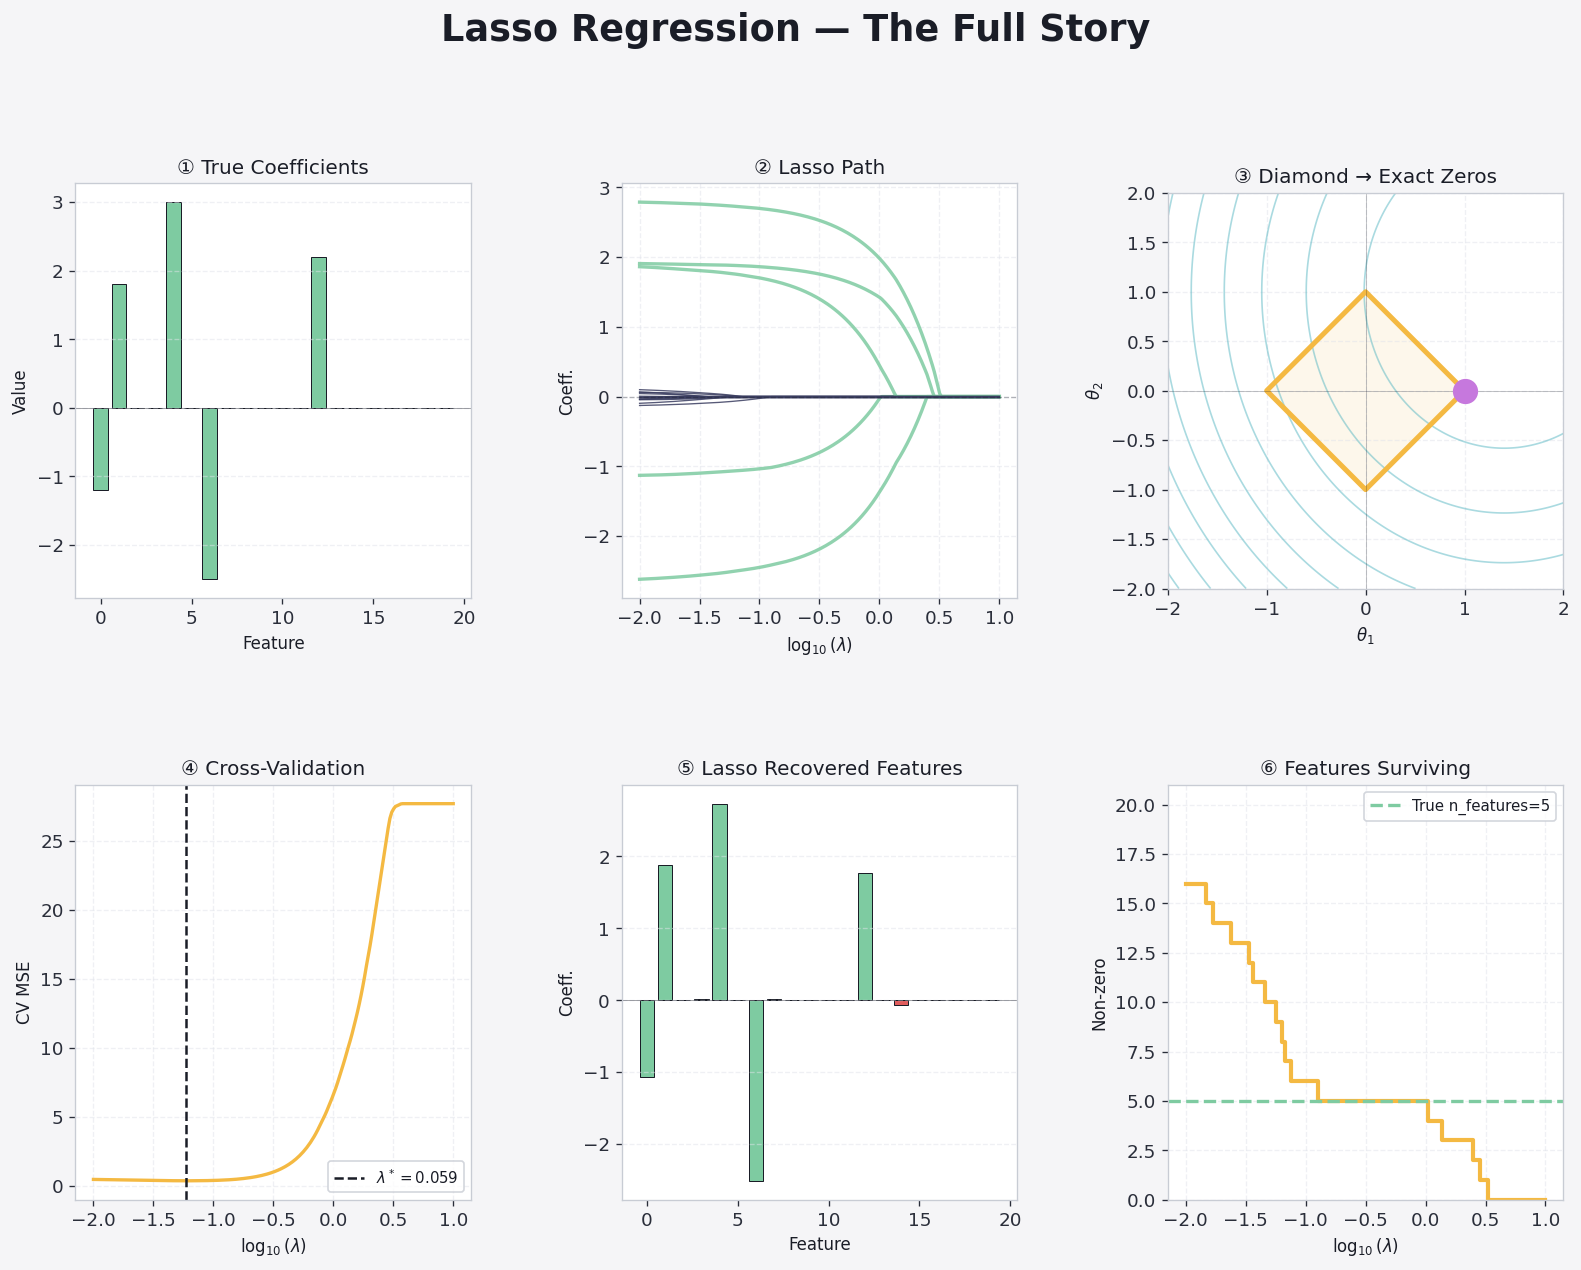

In [11]:
fig = plt.figure(figsize=(16, 11), facecolor='#f5f5f7')
gs  = GridSpec(2, 3, figure=fig, hspace=0.45, wspace=0.38)

# ── (0,0) True vs OLS coefficients ───────────────────────────────────────
ax = fig.add_subplot(gs[0, 0])
ax.bar(feature_idx, theta_true,
       color=[C_TRUE if i in relevant else '#2a2d40' for i in range(n_features)],
       edgecolor='#1a1d27', lw=0.6)
ax.axhline(0, color='#1a1d27', lw=0.6, alpha=0.4)
ax.set_title('① True Coefficients', fontsize=12)
ax.set_xlabel('Feature', fontsize=10); ax.set_ylabel('Value', fontsize=10)
ax.grid(True, axis='y')

# ── (0,1) Lasso path ─────────────────────────────────────────────────────
ax = fig.add_subplot(gs[0, 1])
for j in range(n_features):
    col = C_TRUE if j in relevant else '#3a3d60'
    lw  = 2.0 if j in relevant else 0.8
    ax.plot(np.log10(alphas_path), coef_path[:, j], color=col, lw=lw, alpha=0.85)
ax.axhline(0, color='#1a1d27', ls='--', lw=0.8, alpha=0.3)
ax.set_title('② Lasso Path', fontsize=12)
ax.set_xlabel('$\\log_{10}(\\lambda)$', fontsize=10); ax.set_ylabel('Coeff.', fontsize=10)
ax.grid(True)

# ── (0,2) Geometry: L1 diamond ───────────────────────────────────────────
ax = fig.add_subplot(gs[0, 2])
T1g, T2g = np.meshgrid(np.linspace(-2,2,200), np.linspace(-2,2,200))
J_g = (T1g - 1.4)**2 + 0.8*(T2g - 1.0)**2
ax.contour(T1g, T2g, J_g, levels=10, colors='#56b6c2', linewidths=1, alpha=0.5)
dx = np.array([1, 0, -1, 0, 1]); dy = np.array([0, 1, 0, -1, 0])
ax.plot(dx, dy, color=C_LASSO, lw=3)
ax.fill(dx, dy, color=C_LASSO, alpha=0.1)
ax.scatter([1], [0], s=200, c=C_HL, zorder=8)
ax.axhline(0, color='#1a1d27', lw=0.5, alpha=0.3)
ax.axvline(0, color='#1a1d27', lw=0.5, alpha=0.3)
ax.set_aspect('equal')
ax.set_title('③ Diamond → Exact Zeros', fontsize=12)
ax.set_xlabel('$\\theta_1$', fontsize=10); ax.set_ylabel('$\\theta_2$', fontsize=10)
ax.grid(True); ax.set_xlim(-2,2); ax.set_ylim(-2,2)

# ── (1,0) CV curve ───────────────────────────────────────────────────────
ax = fig.add_subplot(gs[1, 0])
ax.plot(np.log10(alphas_path), cv_errs, color=C_LASSO, lw=2)
ax.axvline(np.log10(best_alpha), color='#1a1d27', ls='--', lw=1.5,
           label=f'$\\lambda^*={best_alpha:.3f}$')
ax.set_title('④ Cross-Validation', fontsize=12)
ax.set_xlabel('$\\log_{10}(\\lambda)$', fontsize=10); ax.set_ylabel('CV MSE', fontsize=10)
ax.grid(True); ax.legend(fontsize=9)

# ── (1,1) Lasso recovered ────────────────────────────────────────────────
ax = fig.add_subplot(gs[1, 1])
bar_c = [C_TRUE if (theta_true[i]!=0) else
         C_ZERO if (abs(lasso_best.coef_[i])>0.05) else '#3a3d60'
         for i in range(n_features)]
ax.bar(feature_idx, lasso_best.coef_, color=bar_c, edgecolor='#1a1d27', lw=0.6)
ax.axhline(0, color='#1a1d27', lw=0.6, alpha=0.4)
ax.set_title('⑤ Lasso Recovered Features', fontsize=12)
ax.set_xlabel('Feature', fontsize=10); ax.set_ylabel('Coeff.', fontsize=10)
ax.grid(True, axis='y')

# ── (1,2) n_nonzero vs lambda ─────────────────────────────────────────────
ax = fig.add_subplot(gs[1, 2])
n_nz = np.sum(np.abs(coef_path) > 1e-4, axis=1)
ax.step(np.log10(alphas_path), n_nz, color=C_LASSO, lw=2.5, where='post')
ax.axhline(n_relevant, color=C_TRUE, ls='--', lw=2, label=f'True n_features={n_relevant}')
ax.set_title('⑥ Features Surviving', fontsize=12)
ax.set_xlabel('$\\log_{10}(\\lambda)$', fontsize=10); ax.set_ylabel('Non-zero', fontsize=10)
ax.grid(True); ax.legend(fontsize=9); ax.set_ylim(0, n_features+1)

fig.suptitle('Lasso Regression — The Full Story', fontsize=22, fontweight='bold',
             color='#1a1d27', y=1.01)
plt.show()

---
## ⚖️ When to use Lasso — and when not to

| Situation | Lasso | Ridge | Elastic Net |
|---|---|---|---|
| Want sparse model       | ✅ zeroes coefficients | ❌ shrinks but keeps all | ✅ |
| Highly correlated features | ❌ picks one arbitrarily | ✅ shares evenly | ✅ best of both |
| $p \gg n$               | ✅ but max $n$ non-zero | ✅ | ✅ |
| Need closed form        | ❌ coordinate descent | ✅ | ❌ |

> Use **Lasso** when you genuinely believe most features are irrelevant. Use **Elastic Net** when correlated features should enter or leave the model **as a group**.


---
## 🎯 Try this

1. **Sparsity vs $\lambda$.** Sweep $\lambda$ from $10^{-4}$ to $10^{1}$ and plot the number of non-zero coefficients — the regularisation path should show coefficients dropping out one by one.
2. **Correlated twin.** Add a near-copy of one informative feature. Refit Lasso ten times with different bootstraps and observe which of the two it selects — Lasso is unstable here; Elastic Net is not.
3. **Solve by coordinate descent.** Implement one pass of soft-thresholding $\theta_j \leftarrow S_\lambda\bigl(\sum_i x_{ij}(y_i - \hat y_i^{(-j)})\bigr) / \sum_i x_{ij}^2$ in numpy and confirm it agrees with sklearn after a few passes.


---
## Summary

| Concept | Formula | Key Insight |
|---|---|---|
| Lasso cost | $J_\text{Lasso}(\theta) = J(\theta) + \lambda \sum_j \lvert\theta_j\rvert$ | L1 penalty — creates **exact zeros** |
| L1 geometry | $\lVert\theta\rVert_1 \leq t$ → diamond | Corners on axes → solutions with zero components |
| L2 geometry | $\lVert\theta\rVert_2^2 \leq t$ → sphere | No corners → solutions rarely exactly zero |
| Regularisation path | Coefficients vs $\lambda$ | Features drop out one by one as $\lambda$ grows |
| Feature selection | Zeroed-out $\theta_j$ | Automatically identifies irrelevant features |
| $\lambda=0$ | OLS (all features, possibly overfitting) | No regularisation |
| $\lambda \to \infty$ | All $\theta_j = 0$ | Maximum sparsity |
| Optimal $\lambda$ | Chosen by cross-validation | Minimises held-out error |

| | Ridge | Lasso |
|---|---|---|
| Penalty | $\lambda\lVert\theta\rVert_2^2$ | $\lambda\lVert\theta\rVert_1$ |
| Zeros? | No — all coefficients shrink | **Yes** — some become exactly 0 |
| Best for | All features somewhat relevant | Sparse: only a few features matter |

**Key insight:** Lasso's L1 penalty creates exact zeros because the cost function meets the diamond-shaped constraint at a corner. This makes Lasso a natural feature-selection tool — it simultaneously fits the model and identifies which features to keep.